In [1]:
%pip install -Uq "unstructured[all-docs]" pillow lxml pillow
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq
%pip install -Uq python_dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from unstructured.partition.pdf import partition_pdf

output_path = "./content/"
file_path = output_path + 'HR Handbook.pdf'


chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            
    strategy="hi_res",                     
    extract_image_block_types=["Image"],   
    extract_image_block_to_payload=True,   
    chunking_strategy="by_title",          
    max_characters=10000,                 
    combine_text_under_n_chars=2000,      
    new_after_n_chars=6000,
        
)

No languages specified, defaulting to English.
Loading weights: 100%|██████████| 367/367 [00:00<00:00, 3282.52it/s]


In [4]:
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [5]:
elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '8a79a022-3e5a-45bd-8667-d6a33bebc425',
 'text': '  ',
 'metadata': {'coordinates': {'points': ((np.float64(371.87499999999994),
     np.float64(172.06874999999968)),
    (np.float64(371.87499999999994), np.float64(406.097222222222)),
    (np.float64(615.1736111111111), np.float64(406.097222222222)),
    (np.float64(615.1736111111111), np.float64(172.06874999999968))),
   'system': 'PixelSpace',
   'layout_width': 2894,
   'layout_height': 4094},
  'last_modified': '2026-05-27T15:33:00',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCADqAPMDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRk

In [ ]:

tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [ ]:

def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

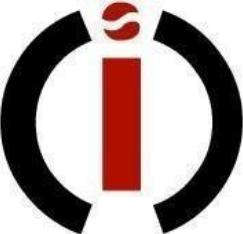

In [8]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [9]:
%pip install -Uq langchain-groq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [ ]:
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

model = ChatGroq(temperature=0.5, model="llama-3.1-8b-instant")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [12]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 1})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 1})

In [15]:
import os
from dotenv import load_dotenv

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

print(groq_api_key[:10])

gsk_w9bH9u


In [16]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt_template = """Describe the image in detail. For context,
the image is part of a research paper explaining the transformers
architecture. Be specific about graphs, such as bar plots."""

messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {
                    "url": "data:image/jpeg;base64,{image}"
                },
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

vision_model = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key=groq_api_key,
    temperature=0
)

chain = prompt | vision_model | StrOutputParser()

In [19]:
image_summaries = chain.batch(
    [{"image": img} for img in images[:3]],
    {"max_concurrency": 1}
)

In [20]:
print(image_summaries[0])

The image does not depict a graph or a bar plot. Instead, it appears to be a logo or a stylized letter combination. 

The logo features a large, black, curved line that forms a partial circle with a gap at the bottom. Inside the curved line, there is a red vertical rectangle, and above it, a red circle with a white curved line running through its center. The background of the image is plain white.

There are no graphs, bar plots, or any other types of visualizations typically found in a research paper about the transformers architecture. The image seems to be a symbolic representation rather than a data visualization.


In [30]:
%pip install -U langchain
%pip install langchain==0.2.16
%pip install langchain-core==0.2.38
%pip install langchain-community==0.2.16

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     -- ------------------------------------- 1.0/15.8 MB 5.0 MB/s eta 0:00:03
     ---- ----------------------------------- 1.8/15.8 MB 4.3 MB/s eta 0:00:04
     -------- ------------------------------- 3.4/15.8 MB 5.1 MB/s eta 0:00:03
     ----------- ---------------------------- 4.5/15.8 MB 5.3 MB/s eta 0:00:03
     -------------- ------------------------- 5.8/15.8 MB 5.4 MB/s eta 0:00:02
     ----------------- ---------------------- 7.1/15.8 MB 5.6 MB/s eta 0:00:02
     --------------------- ------------------ 8.4/15.8 MB 5.6 MB/s eta 0:00:02
     ------------------------ --------------- 9.7/15.8 MB 5.8 MB/s eta 0:00:02
     --------------------------- ------------ 11.0/15.8 MB 5.8 MB/s eta 0:00:01
     ------------------------------- -------- 12.3/15.8 MB 5.8 MB/s eta 

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      + c:\Users\vedik\AppData\Local\Programs\Python\Python313\python.exe C:\Users\vedik\AppData\Local\Temp\pip-install-s1zokg0w\numpy_194c732fff0e4a1cb1ecc48f920d7e16\vendored-meson\meson\meson.py setup C:\Users\vedik\AppData\Local\Temp\pip-install-s1zokg0w\numpy_194c732fff0e4a1cb1ecc48f920d7e16 C:\Users\vedik\AppData\Local\Temp\pip-install-s1zokg0w\numpy_194c732fff0e4a1cb1ecc48f920d7e16\.mesonpy-xpe6az1y -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\vedik\AppData\Local\Temp\pip-install-s1zokg0w\numpy_194c732fff0e4a1cb1ecc48f920d7e16\.mesonpy-xpe6az1y\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\vedik\AppData\Local\Temp\pip-install-s1zokg0w\numpy_194c732fff0e4a1cb1ecc48f920d7e16
      Build dir: C:\Users\vedik\AppData\Local\Temp\pip-install-s1z

  Using cached langsmith-0.1.147-py3-none-any.whl.metadata (14 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
Using cached packaging-24.2-py3-none-any.whl (65 kB)

  Attempting uninstall: tenacity

    Found existing installation: tenacity 9.1.4

    Uninstalling tenacity-9.1.4:

      Successfully uninstalled tenacity-9.1.4

   ---------------------------------------- 0/4 [tenacity]
   ---------------------------------------- 0/4 [tenacity]
  Attempting uninstall: packaging
   ---------------------------------------- 0/4 [tenacity]
    Found existing installation: packaging 25.0
   ---------------------------------------- 0/4 [tenacity]
    Uninstalling packaging-25.0:
   ---------------------------------------- 0/4 [tenacity]
      Successfully uninstalled packaging-25.0
   ---------------------------------------- 0/4 [tenacity]
   ---------- ----------------------------- 1/4 [packaging]
   ---------- ----------------------------- 1/4 [packaging]
   ---------- -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.3.2 requires langchain-core<2.0.0,>=1.4.0, but you have langchain-core 0.2.38 which is incompatible.
langchain-classic 1.0.7 requires langchain-core<2.0.0,>=1.3.3, but you have langchain-core 0.2.38 which is incompatible.
langchain-community 0.4.2 requires langchain-core<2.0.0,>=1.4.0, but you have langchain-core 0.2.38 which is incompatible.
langchain-groq 1.1.2 requires langchain-core<2.0.0,>=1.2.8, but you have langchain-core 0.2.38 which is incompatible.
langchain-nvidia-ai-endpoints 1.4.0 requires langchain-core<2.0.0,>=1.2.5, but you have langchain-core 0.2.38 which is incompatible.
langchain-openai 1.2.2 requires langchain-core<2.0.0,>=1.4.0, but you have langchain-core 0.2.38 whic

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      + c:\Users\vedik\AppData\Local\Programs\Python\Python313\python.exe C:\Users\vedik\AppData\Local\Temp\pip-install-qbec4aso\numpy_583a079c4a984baeb5280bc4c964f154\vendored-meson\meson\meson.py setup C:\Users\vedik\AppData\Local\Temp\pip-install-qbec4aso\numpy_583a079c4a984baeb5280bc4c964f154 C:\Users\vedik\AppData\Local\Temp\pip-install-qbec4aso\numpy_583a079c4a984baeb5280bc4c964f154\.mesonpy-0246m0dy -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\vedik\AppData\Local\Temp\pip-install-qbec4aso\numpy_583a079c4a984baeb5280bc4c964f154\.mesonpy-0246m0dy\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\vedik\AppData\Local\Temp\pip-install-qbec4aso\numpy_583a079c4a984baeb5280bc4c964f154
      Build dir: C:\Users\vedik\AppData\Local\Temp\pip-install-qbe

In [37]:
%pip install langchain

  Using cached langchain_core-1.4.0-py3-none-any.whl.metadata (4.5 kB)
Using cached langchain_core-1.4.0-py3-none-any.whl (548 kB)

  Attempting uninstall: langsmith

    Found existing installation: langsmith 0.1.147

    Uninstalling langsmith-0.1.147:

      Successfully uninstalled langsmith-0.1.147

   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   ---------------------------------------- 0/2 [langsmith]
   -------------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import uuid

from langchain_community.vectorstores import Chroma
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings


embedding_function = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


vectorstore = Chroma(
    collection_name="multi_modal_rag",
    embedding_function=embedding_function
)


store = InMemoryStore()

id_key = "doc_id"

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2179.34it/s]


In [41]:
all_docs = (
    text_summaries
    + table_summaries
    + image_summaries
)

In [42]:
vectorstore.add_texts(all_docs)

['d15b00ac-1e6f-4a91-b9e9-bc957277d32c',
 'a94a2514-50d4-4a4a-b582-72dac3efa6f0',
 'c1e7e1a6-ad8a-40fb-b041-91e8332bcab7',
 'be8f1c1b-f0c5-4e35-80a9-8d3c78521704',
 'f28038c6-0b53-4114-acd8-8ac16f590a53',
 '3d1edb13-ad09-4f5c-b8e7-e69f0600bbf9',
 '02fe537b-f6fb-4685-accb-a359dadc969a',
 'ebc23aa5-9259-46ed-aae9-9e7082f305b6',
 'd8604df0-91bd-48d7-8561-e4a0e12c9031',
 '2ef9df22-cfd5-4e88-9666-67d4062efa26',
 'f3e7eedf-a779-427e-823f-04696970324f',
 '7a23b41e-5888-43ec-93e3-f449e52f55bb',
 '01bebc64-f2dc-4439-8716-ab3874a14752',
 'ab07a85e-ba4d-435f-a98d-1b70133d3928',
 '4c663cb1-7164-4aa8-b9a0-62d98b782799',
 '431dbf68-4a08-47d9-99b6-ebb90cde3692',
 'ba579350-8205-42b8-8783-8ee54f322330',
 'b0ff92b3-d80d-431a-9d09-30abf5c3e3bf',
 '1e9b3b2f-82e6-4f27-947d-27aaaa7b895c',
 '01dea314-deee-47a2-ac4b-64f3934c894c',
 '433fdbc0-2ee4-4ca6-99ec-f2eb86052b06',
 '50dd0dfc-6063-43fd-ac2e-1e4c9d95de1e',
 '32c94e61-476f-48e7-83c6-7bcecc076945',
 'd5fdd409-8a1d-481d-8fde-bec6cfed2a5b',
 'b911c898-d422-

In [44]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

In [45]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langchain_groq import ChatGroq

from base64 import b64decode
def parse_docs(docs):

    b64 = []
    text = []

    for doc in docs:

        try:
            b64decode(doc)
            b64.append(doc)

        except Exception:
            text.append(doc)

    return {
        "images": b64,
        "texts": text
    }
def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""

    if len(docs_by_type["texts"]) > 0:

        for text_element in docs_by_type["texts"]:

            context_text += str(text_element)

    prompt_template = f"""
    Answer the question based only on the following context.

    Context:
    {context_text}

    Question:
    {user_question}
    """

    prompt_content = [
        {
            "type": "text",
            "text": prompt_template
        }
    ]

    if len(docs_by_type["images"]) > 0:

        for image in docs_by_type["images"]:

            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image}"
                    },
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )
vision_model = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key=groq_api_key,
    temperature=0
)
chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | vision_model
    | StrOutputParser()
)

In [47]:
response = chain.invoke(
    "Explain the diagram in the document"
)

print(response)

Based on the provided context, there is no diagram in the document that represents data, such as a graph or a bar plot. Instead, the image appears to be a logo or a stylized letter combination. 

The logo features:
- A large, black, circular or curved shape with gaps.
- Inside the shape, a red vertical rectangle (resembling the letter "i") and a red circle with a white curved line running through it (resembling an "S" shape).

The image seems to be a symbolic representation or a graphic element, possibly used to represent a brand or concept, rather than a data visualization.
